# **Project 2: Joint Detection of AI-Generated Images and Post-Processing Alterations in Real-World Scenarios**

#**Imports**


In [ ]:

import os
import json
import random
import zipfile
import tarfile
import shutil
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision
import torchvision.transforms as transforms
from torchvision import models

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

from google.colab import drive

!pip install -q tqdm requests seaborn torchsummary
import requests
from tqdm.auto import tqdm
import seaborn as sns

import copy
import csv
import time
import hashlib
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from torch.cuda.amp import autocast, GradScaler
import urllib.request


#**Globals**

In [ ]:
SEED = 42
# Fixed seed for reproducibility across Python, NumPy, and PyTorch.
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Automatically select GPU when available, otherwise fall back to CPU.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# Main project directories used to store data, checkpoints, and extracted archives.
ROOT_DIR = Path("/content")
DATA_DIR = ROOT_DIR / "RRDataset"
DOWNLOAD_DIR = ROOT_DIR / "downloads"
EXTRACT_DIR = ROOT_DIR / "RRDataset_extracted"
CHECKPOINT_DIR = ROOT_DIR / "checkpoints"

DOWNLOAD_DIR.mkdir(exist_ok=True)
EXTRACT_DIR.mkdir(exist_ok=True)
CHECKPOINT_DIR.mkdir(exist_ok=True)

# Input resolution and batch size used throughout training and evaluation.
IMG_SIZE = 224
BATCH_SIZE = 32

# Number of epochs for the two training phases.
PHASE1_EPOCHS = 3
PHASE2_EPOCHS = 10

# Labels for the binary real/fake task.
RF_LABELS = {"real": 0, "fake": 1}

# Labels for the transformation classification task.
TRANS_REAL_LABELS = {
    "original": 0,
    "transfer": 1,
    "redigital": 2
}

# Human-readable names used in reports and plots.
TRANS_PRINT_NAMES = {
    0: "original",
    1: "transfer",
    2: "redigital"
}

# Data loading and early stopping parameters.
NUM_WORKERS = 2
PATIENCE = 3
MIN_DELTA = 1e-4

# Paths for saving the best model, metrics, and training history.
BEST_MODEL_PATH = CHECKPOINT_DIR / "best_multitask_model.pt"
METRICS_PATH = CHECKPOINT_DIR / "multitask_metrics.json"
HISTORY_CSV_PATH = CHECKPOINT_DIR / "multitask_history.csv"

# Task weights in the joint loss function.
ALPHA = 0.9
BETA = 1.4
LABEL_SMOOTHING = 0.05

# Learning rates and regularization used in the two training phases.
LR_PHASE1 = 2e-4
LR_PHASE2_HEAD = 1e-4
LR_PHASE2_BACKBONE = 3e-5
WEIGHT_DECAY = 1e-4

# Train/validation/test directories for the real benchmark split.
REAL_TRANSFORM_TRAIN_DIR = ROOT_DIR / "RRDataset_real_train"
REAL_TRANSFORM_VAL_DIR = ROOT_DIR / "RRDataset_real_val"
REAL_TRANSFORM_TEST_DIR = ROOT_DIR / "RRDataset_real_test"

# Maximum number of samples per transformation/class combination for each split.
MAX_SAMPLES_PER_COMBINATION_TRAIN = 1000
MAX_SAMPLES_PER_COMBINATION_VAL = 100
MAX_SAMPLES_PER_COMBINATION_TEST = 100

# DataLoader prefetch factor used when workers are enabled.
PREFETCH_FACTOR = 2

# Zenodo metadata and local directory for the real benchmark archive.
ZENODO_RECORD = "14963880"
ZENODO_API = f"https://zenodo.org/api/records/{ZENODO_RECORD}"
REAL_BENCHMARK_DIR = ROOT_DIR / "RRDataset_real_benchmark"
REAL_BENCHMARK_DIR.mkdir(exist_ok=True)

# Supported image formats in the dataset.
IMG_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

Device: cuda
GPU: Tesla T4


# **Utils**

In [ ]:
def set_seed(seed=42):
    # Ensure reproducibility across Python, NumPy, and PyTorch.
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def count_parameters(model):
    # Count only trainable parameters.
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def download_with_progress(url, output_path, chunk_size=1024 * 1024):
    # Download a file with a progress bar.
    response = requests.get(url, stream=True)
    response.raise_for_status()
    total_size = int(response.headers.get("content-length", 0))

    with open(output_path, "wb") as f, tqdm(
        desc=output_path.name,
        total=total_size,
        unit="B",
        unit_scale=True,
        unit_divisor=1024,
    ) as bar:
        for chunk in response.iter_content(chunk_size=chunk_size):
            if chunk:
                f.write(chunk)
                bar.update(len(chunk))

    print(f"Download completed: {output_path}")

def calculate_md5(file_path):
    # Compute the MD5 checksum of a file.
    hash_md5 = hashlib.md5()
    with open(file_path, "rb") as f:
        for chunk in iter(lambda: f.read(4096), b""):
            hash_md5.update(chunk)
    return hash_md5.hexdigest()

def is_valid_image(image_path):
    # Check whether an image file can be opened correctly.
    try:
        with Image.open(image_path) as img:
            img.verify()
        with Image.open(image_path) as img:
            img.convert("RGB")
        return True
    except Exception:
        return False

def plot_confusion_matrix(cm, class_names, title="Confusion Matrix"):
    # Plot a confusion matrix with seaborn.
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def save_history_to_csv(history, csv_path):
    # Save the training history to a CSV file.
    keys = list(history.keys())
    rows = zip(*[history[k] for k in keys])
    with open(csv_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(keys)
        writer.writerows(rows)

def save_metrics_to_json(metrics_dict, json_path):
    # Save the final metrics to a JSON file.
    with open(json_path, "w") as f:
        json.dump(metrics_dict, f, indent=4)

def report_dataset_balance(dataset, split_name="train"):
    # Print class balance for both tasks.
    rf_counts = defaultdict(int)
    trans_counts = defaultdict(int)

    base_len = len(dataset.samples)

    for idx in range(len(dataset)):
        _, rf_label, trans_label = dataset[idx]
        rf_counts[int(rf_label)] += 1
        trans_counts[int(trans_label)] += 1

    print(f"\n===== Split balance: {split_name} =====")
    print("Real/Fake task:")
    for name, idx in RF_LABELS.items():
        print(f"  {name}: {rf_counts[idx]}")

    print("Transformation task:")
    for idx, name in TRANS_PRINT_NAMES.items():
        print(f"  {name}: {trans_counts[idx]}")

    print(f"Unique base samples: {base_len}")
    print(f"Total multi-task samples: {len(dataset)}")

def build_optimizer_phase1(model):
    # Optimizer for the first training phase.
    return optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR_PHASE1,
        weight_decay=WEIGHT_DECAY
    )

def build_optimizer_phase2(model):
    # Optimizer with different learning rates for backbone and heads.
    params = []

    if any(p.requires_grad for p in model.backbone.layer3.parameters()):
        params.append({
            "params": model.backbone.layer3.parameters(),
            "lr": LR_PHASE2_BACKBONE * 0.8
        })

    params.append({
        "params": model.backbone.layer4.parameters(),
        "lr": LR_PHASE2_BACKBONE
    })
    params.append({
        "params": model.head_rf.parameters(),
        "lr": LR_PHASE2_HEAD
    })
    params.append({
        "params": model.head_trans.parameters(),
        "lr": LR_PHASE2_HEAD
    })

    return optim.AdamW(params, weight_decay=WEIGHT_DECAY)

#**Data**


## **Data Preparation with Real Benchmark Transformations**

### **Subset Selection Strategy**
To reduce the domain gap between training and final evaluation, we do not use synthetic on-the-fly transformations. Instead, we build a balanced subset directly from the real RRDataset benchmark, which contains three transformation categories: original, transfer, and redigital.

From the extracted benchmark, we create a disjoint internal train/validation/test split, while keeping the balance across real/ai classes and transformation categories. This choice is methodologically more sound because the transformation classification task is learned from real benchmark examples rather than artificial simulations.

In [ ]:
def prepare_real_transform_splits(
    source_root,
    train_root,
    val_root,
    test_root,
    val_ratio=0.15,
    test_ratio=0.15,
    seed=42,
    max_per_combination=None
):
    # Fix the random seed so the split is reproducible.
    random.seed(seed)
    source_root = Path(source_root)
    train_root = Path(train_root)
    val_root = Path(val_root)
    test_root = Path(test_root)

    # Find the extracted RRDataset folder inside the source directory.
    candidate_dirs = list(source_root.rglob("RRDataset_final"))
    if len(candidate_dirs) == 0:
        raise FileNotFoundError("RRDataset_final folder not found.")
    base_dir = candidate_dirs[0]

    # Avoid rebuilding the split if the destination folders are already populated.
    already_ready = (
        train_root.exists() and any(train_root.rglob("*")) and
        val_root.exists() and any(val_root.rglob("*")) and
        test_root.exists() and any(test_root.rglob("*"))
    )
    if already_ready:
        print("Train/val/test split already prepared.")
        return

    train_root.mkdir(parents=True, exist_ok=True)
    val_root.mkdir(parents=True, exist_ok=True)
    test_root.mkdir(parents=True, exist_ok=True)

    # Process each transformation and each class separately to keep the split balanced.
    for trans_folder in ["original", "transfer", "redigital"]:
        for rf_folder in ["real", "ai"]:
            src_dir = base_dir / trans_folder / rf_folder
            if not src_dir.exists():
                continue

            # Collect all valid images for the current combination.
            imgs = [p for p in sorted(src_dir.rglob("*")) if p.suffix.lower() in IMG_EXTENSIONS]
            random.shuffle(imgs)

            # Limit the number of samples if a cap is provided.
            if max_per_combination is not None:
                imgs = imgs[:max_per_combination]

            # Split the current combination into train, validation, and test subsets.
            n = len(imgs)
            n_test = int(n * test_ratio)
            n_val = int(n * val_ratio)
            n_train = n - n_val - n_test

            train_imgs = imgs[:n_train]
            val_imgs = imgs[n_train:n_train + n_val]
            test_imgs = imgs[n_train + n_val:]

            dst_train = train_root / trans_folder / rf_folder
            dst_val = val_root / trans_folder / rf_folder
            dst_test = test_root / trans_folder / rf_folder

            dst_train.mkdir(parents=True, exist_ok=True)
            dst_val.mkdir(parents=True, exist_ok=True)
            dst_test.mkdir(parents=True, exist_ok=True)

            # Copy files into their final split folders.
            for p in train_imgs:
                shutil.copy2(p, dst_train / p.name)
            for p in val_imgs:
                shutil.copy2(p, dst_val / p.name)
            for p in test_imgs:
                shutil.copy2(p, dst_test / p.name)

    print("Real train/val/test split created.")


# Load the Zenodo metadata to locate the correct archive.
with urllib.request.urlopen(ZENODO_API) as response:
    record_meta = json.loads(response.read().decode())

files_in_record = record_meta.get("files", [])

# Select the archive containing the real benchmark transformations.
real_transform_file = files_in_record[1]
real_transform_url = real_transform_file["links"]["self"]
real_transform_name = real_transform_file["key"]
real_transform_dest = DOWNLOAD_DIR / real_transform_name

# Download the dataset only if it is not already available locally.
if not real_transform_dest.exists():
    print("Downloading real benchmark dataset:", real_transform_name)
    download_with_progress(real_transform_url, real_transform_dest)
else:
    print("Real dataset already present:", real_transform_dest)

# Extract the archive only once to avoid repeating the operation.
if not any(REAL_BENCHMARK_DIR.iterdir()):
    print("Extracting real benchmark dataset...")
    with tarfile.open(real_transform_dest, "r:gz") as tf:
        tf.extractall(REAL_BENCHMARK_DIR)
    print("Extraction completed in:", REAL_BENCHMARK_DIR)
else:
    print("Real dataset already extracted in:", REAL_BENCHMARK_DIR)

# Build the train/validation/test split from the extracted benchmark.
prepare_real_transform_splits(
    source_root=REAL_BENCHMARK_DIR,
    train_root=REAL_TRANSFORM_TRAIN_DIR,
    val_root=REAL_TRANSFORM_VAL_DIR,
    test_root=REAL_TRANSFORM_TEST_DIR,
    val_ratio=0.15,
    test_ratio=0.15,
    seed=SEED,
    max_per_combination=(
        MAX_SAMPLES_PER_COMBINATION_TRAIN +
        MAX_SAMPLES_PER_COMBINATION_VAL +
        MAX_SAMPLES_PER_COMBINATION_TEST
    )
)

RRDataset_test.tar.gz:   0%|          | 0.00/18.7G [00:00<?, ?B/s]

Download completed: /content/downloads/RRDataset_test.tar.gz
Extracting real benchmark dataset...


/tmp/ipykernel_1639/119370759.py:105: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tf.extractall(REAL_BENCHMARK_DIR)


Extraction completed in: /content/RRDataset_real_benchmark
Real train/val/test split created.


In [ ]:
class MultiTaskRealRRDataset(Dataset):
    def __init__(self, root_dir, transform=None, validate_files=True, max_samples_per_combination=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.samples = []

        # Read samples for each transformation and each class separately.
        for trans_name, trans_idx in TRANS_REAL_LABELS.items():
            trans_dir = self.root_dir / trans_name
            if not trans_dir.exists():
                continue

            for rf_folder_name, rf_label in [("real", 0), ("ai", 1)]:
                class_dir = trans_dir / rf_folder_name
                if not class_dir.exists():
                    continue

                class_samples = []
                for img_p in sorted(class_dir.rglob("*")):
                    if img_p.suffix.lower() in IMG_EXTENSIONS:
                        if (not validate_files) or is_valid_image(img_p):
                            class_samples.append((img_p, rf_label, trans_idx))

                # Keep the subset size controlled for each combination.
                if max_samples_per_combination is not None:
                    class_samples = class_samples[:max_samples_per_combination]

                self.samples.extend(class_samples)

        print(f"[real-transform dataset] Valid samples found: {len(self.samples)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, rf_label, trans_label = self.samples[idx]
        img = Image.open(img_path).convert("RGB")

        # Apply the selected preprocessing pipeline.
        if self.transform:
            img = self.transform(img)

        return (
            img,
            torch.tensor(rf_label, dtype=torch.long),
            torch.tensor(trans_label, dtype=torch.long)
        )


# Stronger augmentation for training only.
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.86, 1.0), ratio=(0.92, 1.08)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.08),
    transforms.RandomRotation(5),
    transforms.RandomApply(
        [transforms.ColorJitter(brightness=0.10, contrast=0.10, saturation=0.07, hue=0.025)],
        p=0.25
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Validation uses only deterministic preprocessing.
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Build the training subset.
train_dataset = MultiTaskRealRRDataset(
    REAL_TRANSFORM_TRAIN_DIR,
    transform=train_transform,
    max_samples_per_combination=MAX_SAMPLES_PER_COMBINATION_TRAIN
)

# Build the validation subset.
val_dataset = MultiTaskRealRRDataset(
    REAL_TRANSFORM_VAL_DIR,
    transform=val_transform,
    max_samples_per_combination=MAX_SAMPLES_PER_COMBINATION_VAL
)

# Check that the split remains balanced.
report_dataset_balance(train_dataset, split_name="train")
report_dataset_balance(val_dataset, split_name="val")

# DataLoaders for efficient batch loading on GPU.
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0),
    prefetch_factor=PREFETCH_FACTOR if NUM_WORKERS > 0 else None,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0),
    prefetch_factor=PREFETCH_FACTOR if NUM_WORKERS > 0 else None
)

print(f"Total training samples: {len(train_dataset)}")
print(f"Total validation samples: {len(val_dataset)}")

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (109721600 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


[real-transform dataset] Valid samples found: 5040
[real-transform dataset] Valid samples found: 600

===== Split balance: train =====
Real/Fake task:
  real: 2520
  fake: 2520
Transformation task:
  original: 1680
  transfer: 1680
  redigital: 1680
Unique base samples: 5040
Total multi-task samples: 5040

===== Split balance: val =====
Real/Fake task:
  real: 300
  fake: 300
Transformation task:
  original: 200
  transfer: 200
  redigital: 200
Unique base samples: 600
Total multi-task samples: 600
Total training samples: 5040
Total validation samples: 600


#**Network**

## **Unified Multi-Task Model (Shared Backbone)**

### **Architectural choices**

To simultaneously capture heterogeneous visual cues, we use a pre-trained ResNet50 on ImageNet as a shared backbone. This choice is motivated by the fact that the two tasks rely on different kinds of evidence: the Real/Fake task often depends on subtle high-frequency cues and microscopic irregularities, while the Transformation task benefits more from global information such as texture consistency, blur patterns, and overall image statistics.

We remove the native classification layer of the backbone by replacing it with `fc = nn.Identity()`, so that the network outputs a feature vector of size 2048 instead of a final ImageNet prediction. On top of this shared representation, we attach two independent parallel linear heads:
- `head_rf`: a fully connected layer that maps the shared features to 2 classes, Real vs AI-generated.
- `head_trans`: a parallel fully connected layer that maps the same features to 3 classes, corresponding to the type of post-processing transformation.

This multi-task design allows the model to learn a common visual representation while specializing each head for its own objective, which is especially useful when the two tasks are related but not identical.

In [ ]:
class MultiTaskModel(nn.Module):
    def __init__(self, backbone_name="resnet50", pretrained=True):
        super(MultiTaskModel, self).__init__()

        # Load a pre-trained ResNet50 backbone for shared feature extraction.
        if backbone_name == "resnet50":
            weights = models.ResNet50_Weights.DEFAULT if pretrained else None
            self.backbone = models.resnet50(weights=weights)

            # The original classification layer is replaced by identity so the model outputs features only.
            num_features = self.backbone.fc.in_features
            self.backbone.fc = nn.Identity()
        else:
            raise ValueError("Unsupported backbone.")

        # Task-specific head for binary Real/Fake classification.
        self.head_rf = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(num_features, 2)
        )

        # Task-specific head for 3-class Transformation classification.
        self.head_trans = nn.Sequential(
            nn.Dropout(p=0.35),
            nn.Linear(num_features, 3)
        )

    def forward(self, x):
        # Extract shared visual features once and feed them to both heads.
        features = self.backbone(x)
        out_rf = self.head_rf(features)
        out_trans = self.head_trans(features)
        return out_rf, out_trans


def freeze_all_backbone(model):
    # Freeze the entire backbone during the first training stage.
    for param in model.backbone.parameters():
        param.requires_grad = False

    # Keep both task heads trainable.
    for param in model.head_rf.parameters():
        param.requires_grad = True
    for param in model.head_trans.parameters():
        param.requires_grad = True


def unfreeze_last_block(model):
    # Fine-tune only the last ResNet block to adapt high-level features.
    for param in model.backbone.layer4.parameters():
        param.requires_grad = True


def unfreeze_layer3_and_4(model):
    # Gradually unfreeze deeper backbone blocks for stronger fine-tuning.
    for param in model.backbone.layer3.parameters():
        param.requires_grad = True
    for param in model.backbone.layer4.parameters():
        param.requires_grad = True

# **Train**

## **Joint Loss Function and Training**

The global optimization objective of the model is defined as a weighted linear combination of the two task-specific cross-entropy losses:

$$L_{total} = \alpha \cdot L_{RF} + \beta \cdot L_{Trans}$$

Here, `loss_RF` is the loss for the Real/Fake classification task, while `loss_Trans` is the loss for the Transformation classification task. In this baseline configuration, we set `alpha = 1.0` and `beta = 1.0`, giving the two objectives equal importance. This means that the network is trained to improve both tasks simultaneously, without privileging one over the other.

To stabilize optimization and reduce overfitting, we use AdamW with a small learning rate and weight decay, which is particularly suitable when fine-tuning a pre-trained backbone together with lightweight classification heads. Since the model is trained in mixed precision, gradient scaling is also used to preserve numerical stability. During training, gradient clipping is applied to prevent excessively large updates, especially when the heads and the backbone are optimized together.

In [ ]:
# Enable mixed-precision training only when a CUDA device is available.
scaler = GradScaler(enabled=torch.cuda.is_available())

# Cross-entropy losses for the two tasks, with label smoothing for better generalization.
criterion_rf = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
criterion_trans = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

def train_epoch(model, dataloader, optimizer, device):
    model.train()
    running_loss = 0.0
    correct_rf, correct_trans = 0, 0
    total = 0

    for imgs, rf_labels, trans_labels in tqdm(dataloader, desc="Training"):
        imgs = imgs.to(device, non_blocking=True)
        rf_labels = rf_labels.to(device, non_blocking=True)
        trans_labels = trans_labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        # Forward pass in mixed precision to improve speed and reduce memory usage.
        with autocast(enabled=torch.cuda.is_available()):
            out_rf, out_trans = model(imgs)
            loss_rf = criterion_rf(out_rf, rf_labels)
            loss_trans = criterion_trans(out_trans, trans_labels)
            total_loss = (ALPHA * loss_rf) + (BETA * loss_trans)

        # Scale gradients before backpropagation to preserve numerical stability.
        scaler.scale(total_loss).backward()
        scaler.unscale_(optimizer)

        # Clip gradients to avoid unstable updates during fine-tuning.
        torch.nn.utils.clip_grad_norm_(
            filter(lambda p: p.requires_grad, model.parameters()),
            max_norm=1.0
        )
        scaler.step(optimizer)
        scaler.update()

        running_loss += total_loss.item() * imgs.size(0)

        _, pred_rf = torch.max(out_rf, 1)
        _, pred_trans = torch.max(out_trans, 1)

        correct_rf += (pred_rf == rf_labels).sum().item()
        correct_trans += (pred_trans == trans_labels).sum().item()
        total += imgs.size(0)

    return running_loss / total, correct_rf / total, correct_trans / total


def validate(model, dataloader, device):
    model.eval()
    running_loss = 0.0
    all_rf_preds, all_rf_labels = [], []
    all_trans_preds, all_trans_labels = [], []

    # No gradients are computed during validation.
    with torch.no_grad():
        for imgs, rf_labels, trans_labels in dataloader:
            imgs = imgs.to(device, non_blocking=True)
            rf_labels = rf_labels.to(device, non_blocking=True)
            trans_labels = trans_labels.to(device, non_blocking=True)

            # Use the same forward and loss computation as in training.
            with autocast(enabled=torch.cuda.is_available()):
                out_rf, out_trans = model(imgs)
                loss_rf = criterion_rf(out_rf, rf_labels)
                loss_trans = criterion_trans(out_trans, trans_labels)
                total_loss = (ALPHA * loss_rf) + (BETA * loss_trans)

            running_loss += total_loss.item() * imgs.size(0)

            _, pred_rf = torch.max(out_rf, 1)
            _, pred_trans = torch.max(out_trans, 1)

            all_rf_preds.extend(pred_rf.cpu().numpy())
            all_rf_labels.extend(rf_labels.cpu().numpy())
            all_trans_preds.extend(pred_trans.cpu().numpy())
            all_trans_labels.extend(trans_labels.cpu().numpy())

    total = len(dataloader.dataset)
    acc_rf = accuracy_score(all_rf_labels, all_rf_preds)
    acc_trans = accuracy_score(all_trans_labels, all_trans_preds)
    macro_f1_trans = f1_score(all_trans_labels, all_trans_preds, average="macro")

    return (
        running_loss / total,
        acc_rf,
        acc_trans,
        macro_f1_trans,
        all_rf_preds,
        all_rf_labels,
        all_trans_preds,
        all_trans_labels
    )

# Initialize the multi-task model on the selected device.
model = MultiTaskModel(backbone_name="resnet50", pretrained=True).to(DEVICE)

# Phase 1: freeze the whole backbone and train only the task heads.
freeze_all_backbone(model)
print(f"Phase 1 - trainable params: {count_parameters(model):,}")

# Optimizer and scheduler for the first training phase.
optimizer = build_optimizer_phase1(model)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.7, patience=1, min_lr=1e-6
)

# Store training and validation metrics across epochs.
history = {
    "epoch": [],
    "phase": [],
    "train_loss": [],
    "train_acc_rf": [],
    "train_acc_trans": [],
    "val_loss": [],
    "val_acc_rf": [],
    "val_acc_trans": [],
    "lr": []
}

# Track the best validation result and keep a copy of the best weights.
best_val_loss = float("inf")
best_val_trans = -1.0
best_val_f1_trans = -1.0
best_epoch = -1
best_phase = ""
best_model_wts = copy.deepcopy(model.state_dict())
patience_counter = 0
start_time = time.time()

# -------------------------
# PHASE 1: train heads only
# -------------------------
for epoch in range(PHASE1_EPOCHS):
    print(f"\n===== PHASE 1 - EPOCH {epoch+1}/{PHASE1_EPOCHS} =====")
    train_loss, train_acc_rf, train_acc_trans = train_epoch(model, train_loader, optimizer, DEVICE)
    val_loss, val_acc_rf, val_acc_trans, val_f1_trans, _, _, _, _ = validate(model, val_loader, DEVICE)

    # Update the learning rate based on validation Macro-F1.
    scheduler.step(val_f1_trans)
    current_lr = optimizer.param_groups[0]["lr"]

    history["epoch"].append(epoch + 1)
    history["phase"].append("phase_1")
    history["train_loss"].append(train_loss)
    history["train_acc_rf"].append(train_acc_rf)
    history["train_acc_trans"].append(train_acc_trans)
    history["val_loss"].append(val_loss)
    history["val_acc_rf"].append(val_acc_rf)
    history["val_acc_trans"].append(val_acc_trans)
    history["lr"].append(current_lr)

    print(f"Current LR: {current_lr:.2e}")
    print(f"Train Loss: {train_loss:.4f} | Train RF Acc: {train_acc_rf:.4f} | Train Trans Acc: {train_acc_trans:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val RF Acc: {val_acc_rf:.4f} | Val Trans Acc: {val_acc_trans:.4f}")

    # Best model selection prioritizes transformation Macro-F1, then transformation accuracy, then validation loss.
    improved = (
        (val_f1_trans > best_val_f1_trans + MIN_DELTA) or
        (abs(val_f1_trans - best_val_f1_trans) <= MIN_DELTA and val_acc_trans > best_val_trans + MIN_DELTA) or
        (abs(val_f1_trans - best_val_f1_trans) <= MIN_DELTA and abs(val_acc_trans - best_val_trans) <= MIN_DELTA and val_loss < best_val_loss - MIN_DELTA)
    )

    if improved:
        best_val_loss = val_loss
        best_val_trans = val_acc_trans
        best_val_f1_trans = val_f1_trans
        best_epoch = epoch + 1
        best_phase = "phase_1"
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        patience_counter = 0
    else:
        patience_counter += 1

    # Stop early if validation performance stops improving.
    if patience_counter >= PATIENCE:
        print("Early stopping triggered in phase 1.")
        break

patience_counter = 0

# Phase 2: unfreeze the last backbone block for fine-tuning.
unfreeze_last_block(model)
print(f"Phase 2 - trainable params: {count_parameters(model):,}")

# Rebuild optimizer and scheduler for the partially unfrozen backbone.
optimizer = build_optimizer_phase2(model)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.7, patience=1, min_lr=1e-6
)

for epoch in range(PHASE2_EPOCHS):
    # After a few epochs, unfreeze more backbone layers for deeper adaptation.
    if epoch == 4:
        unfreeze_layer3_and_4(model)
        optimizer = build_optimizer_phase2(model)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="max", factor=0.7, patience=1, min_lr=1e-6
        )
        print(f"Layer 3 and 4 unfrozen - trainable params: {count_parameters(model):,}")

    print(f"\n===== PHASE 2 - EPOCH {epoch+1}/{PHASE2_EPOCHS} =====")
    train_loss, train_acc_rf, train_acc_trans = train_epoch(model, train_loader, optimizer, DEVICE)
    val_loss, val_acc_rf, val_acc_trans, val_f1_trans, _, _, _, _ = validate(model, val_loader, DEVICE)

    scheduler.step(val_f1_trans)
    current_lr_backbone = optimizer.param_groups[0]["lr"]
    current_lr_head = optimizer.param_groups[1]["lr"]

    history["epoch"].append(epoch + 1)
    history["phase"].append("phase_2")
    history["train_loss"].append(train_loss)
    history["train_acc_rf"].append(train_acc_rf)
    history["train_acc_trans"].append(train_acc_trans)
    history["val_loss"].append(val_loss)
    history["val_acc_rf"].append(val_acc_rf)
    history["val_acc_trans"].append(val_acc_trans)
    history["lr"].append((current_lr_backbone, current_lr_head))

    print(f"Current LR backbone: {current_lr_backbone:.2e} | heads: {current_lr_head:.2e}")
    print(f"Train Loss: {train_loss:.4f} | Train RF Acc: {train_acc_rf:.4f} | Train Trans Acc: {train_acc_trans:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val RF Acc: {val_acc_rf:.4f} | Val Trans Acc: {val_acc_trans:.4f}")

    improved = (
        (val_f1_trans > best_val_f1_trans + MIN_DELTA) or
        (abs(val_f1_trans - best_val_f1_trans) <= MIN_DELTA and val_acc_trans > best_val_trans + MIN_DELTA) or
        (abs(val_f1_trans - best_val_f1_trans) <= MIN_DELTA and abs(val_acc_trans - best_val_trans) <= MIN_DELTA and val_loss < best_val_loss - MIN_DELTA)
    )

    if improved:
        best_val_loss = val_loss
        best_val_trans = val_acc_trans
        best_val_f1_trans = val_f1_trans
        best_epoch = epoch + 1
        best_phase = "phase_2"
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        print("Early stopping triggered in phase 2.")
        break

elapsed_time = time.time() - start_time
print(f"\nTraining completed in {elapsed_time/60:.2f} minutes.")

# Restore the best weights found during training.
if best_model_wts is not None:
    model.load_state_dict(best_model_wts)
    print(f"Loaded best model from {best_phase}, epoch {best_epoch}, with val_loss={best_val_loss:.4f}")

# Save the training history for later analysis and plotting.
save_history_to_csv(history, HISTORY_CSV_PATH)
print(f"History saved to: {HISTORY_CSV_PATH}")
print(f"Best model saved to: {BEST_MODEL_PATH}")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 163MB/s]


Phase 1 - trainable params: 10,245

===== PHASE 1 - EPOCH 1/3 =====


Training:   0%|          | 0/157 [00:00<?, ?it/s]

Current LR: 2.00e-04
Train Loss: 2.0395 | Train RF Acc: 0.6626 | Train Trans Acc: 0.4492
Val Loss: 1.8728 | Val RF Acc: 0.8717 | Val Trans Acc: 0.5133

===== PHASE 1 - EPOCH 2/3 =====


...

Current LR backbone: 2.40e-05 | heads: 3.00e-05
Train Loss: 0.7121 | Train RF Acc: 0.9554 | Train Trans Acc: 0.9148
Val Loss: 0.9987 | Val RF Acc: 0.9683 | Val Trans Acc: 0.8100

===== PHASE 2 - EPOCH 9/10 =====


Training:   0%|          | 0/157 [00:00<?, ?it/s]

Current LR backbone: 2.40e-05 | heads: 3.00e-05
Train Loss: 0.6494 | Train RF Acc: 0.9672 | Train Trans Acc: 0.9405
Val Loss: 1.0309 | Val RF Acc: 0.9667 | Val Trans Acc: 0.8100

===== PHASE 2 - EPOCH 10/10 =====


Training:   0%|          | 0/157 [00:00<?, ?it/s]

Current LR backbone: 2.40e-05 | heads: 3.00e-05
Train Loss: 0.5981 | Train RF Acc: 0.9757 | Train Trans Acc: 0.9534
Val Loss: 1.0065 | Val RF Acc: 0.9667 | Val Trans Acc: 0.8167

Training completed in 22.83 minutes.
Loaded best model from phase_2, epoch 10, with val_loss=1.0065
History saved to: /content/checkpoints/multitask_history.csv
Best model saved to: /content/checkpoints/best_multitask_model.pt


#**Evaluation/Test**

## **Evaluation and Cross-Class Trace Analysis**

In this final stage, we evaluate the Real/Fake classifier by breaking down its performance according to the specific post-processing transformation applied to each image. This makes it possible to verify the presence of cross-class traces and to identify which alterations are most disruptive to the geometric and structural fingerprints left by AI generation models.

A detailed per-transformation analysis is especially important here because different post-processing operations may preserve or destroy different visual cues. By measuring performance separately on original, transfer, and redigital images, we can better understand how robust the model is under real-world manipulation.

[real-transform dataset] Valid samples found: 600
Total test samples: 600

===== Split balance: test =====
Real/Fake task:
  real: 300
  fake: 300
Transformation task:
  original: 200
  transfer: 200
  redigital: 200
Unique base samples: 600
Total multi-task samples: 600

 FINAL TEST REPORT ON RRDATASET LARGE BENCHMARK 
Test Loss: 1.0439
Test RF Accuracy: 0.9433
Test Transformation Accuracy: 0.8033
Test Macro-F1 Transformation: 0.8036
Test Joint Score: 0.8733


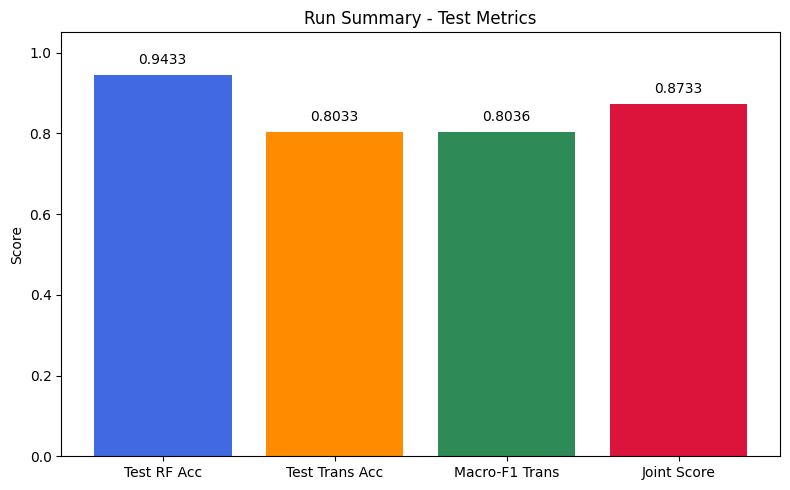

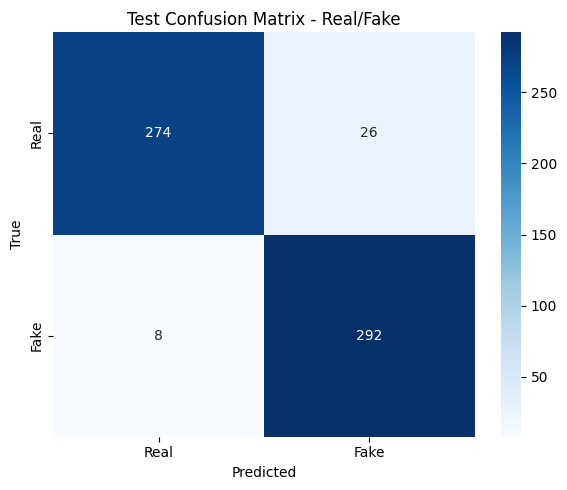

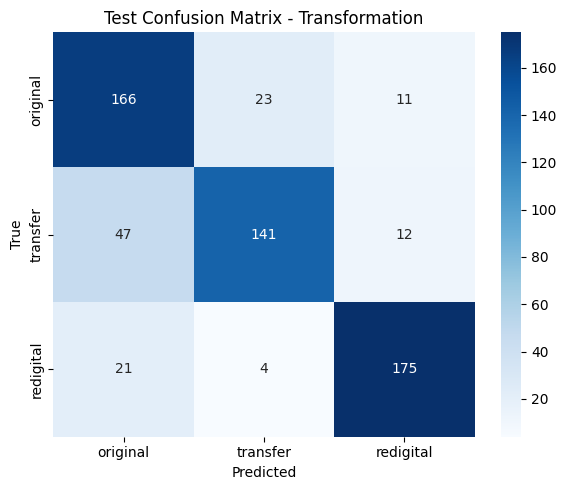


 TEST CLASSIFICATION REPORT: REAL/FAKE 
              precision    recall  f1-score   support

        Real       0.97      0.91      0.94       300
        Fake       0.92      0.97      0.94       300

    accuracy                           0.94       600
   macro avg       0.94      0.94      0.94       600
weighted avg       0.94      0.94      0.94       600


 TEST CLASSIFICATION REPORT: TRANSFORMATION 
              precision    recall  f1-score   support

    original       0.71      0.83      0.76       200
    transfer       0.84      0.70      0.77       200
   redigital       0.88      0.88      0.88       200

    accuracy                           0.80       600
   macro avg       0.81      0.80      0.80       600
weighted avg       0.81      0.80      0.80       600


 DISAGGREGATED TEST ANALYSIS FOR REAL/FAKE TASK 

Overall Real/Fake accuracy on 'ORIGINAL' images: 0.9500
  -> Accuracy on REAL photographs: 0.9200
  -> Accuracy on AI-generated images: 0.9800

Overall Re

In [ ]:
# Test-time preprocessing: resize to the model input size and normalize with ImageNet statistics.
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Build the test dataset from the held-out benchmark split.
test_dataset = MultiTaskRealRRDataset(
    REAL_TRANSFORM_TEST_DIR,
    transform=test_transform,
    max_samples_per_combination=MAX_SAMPLES_PER_COMBINATION_TEST
)

# Create the test DataLoader with deterministic ordering and efficient loading.
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0),
    prefetch_factor=PREFETCH_FACTOR if NUM_WORKERS > 0 else None
)

print(f"Total test samples: {len(test_dataset)}")
report_dataset_balance(test_dataset, split_name="test")

def evaluate_on_test(model, dataloader, device):
    model.eval()
    running_loss = 0.0

    all_rf_preds, all_rf_labels = [], []
    all_trans_preds, all_trans_labels = [], []

    # Evaluation is run without gradient computation.
    with torch.no_grad():
        for imgs, rf_labels, trans_labels in dataloader:
            imgs = imgs.to(device, non_blocking=True)
            rf_labels = rf_labels.to(device, non_blocking=True)
            trans_labels = trans_labels.to(device, non_blocking=True)

            # Forward pass on the test set.
            out_rf, out_trans = model(imgs)

            # Compute the same joint loss used during training.
            loss_rf = criterion_rf(out_rf, rf_labels)
            loss_trans = criterion_trans(out_trans, trans_labels)
            total_loss = (ALPHA * loss_rf) + (BETA * loss_trans)

            running_loss += total_loss.item() * imgs.size(0)

            pred_rf = out_rf.argmax(dim=1)
            pred_trans = out_trans.argmax(dim=1)

            all_rf_preds.extend(pred_rf.cpu().numpy())
            all_rf_labels.extend(rf_labels.cpu().numpy())
            all_trans_preds.extend(pred_trans.cpu().numpy())
            all_trans_labels.extend(trans_labels.cpu().numpy())

    total = len(dataloader.dataset)
    test_loss = running_loss / total
    test_acc_rf = accuracy_score(all_rf_labels, all_rf_preds)
    test_acc_trans = accuracy_score(all_trans_labels, all_trans_preds)

    return (
        test_loss,
        test_acc_rf,
        test_acc_trans,
        np.array(all_rf_preds),
        np.array(all_rf_labels),
        np.array(all_trans_preds),
        np.array(all_trans_labels)
    )

# Load the best checkpoint selected during validation.
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model.eval()

# Run the final evaluation on the held-out test benchmark.
test_loss, test_acc_rf, test_acc_trans, rf_test_preds, rf_test_labels, trans_test_preds, trans_test_labels = evaluate_on_test(
    model, test_loader, DEVICE
)

print("\n=======================================================")
print(" FINAL TEST REPORT ON RRDATASET LARGE BENCHMARK ")
print("=======================================================")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test RF Accuracy: {test_acc_rf:.4f}")
print(f"Test Transformation Accuracy: {test_acc_trans:.4f}")

# Macro-F1 captures class-wise balance for the transformation task.
test_macro_f1_trans = f1_score(trans_test_labels, trans_test_preds, average="macro")

# Joint score summarizes the two task accuracies with equal weight.
test_joint_score = (test_acc_rf + test_acc_trans) / 2

print(f"Test Macro-F1 Transformation: {test_macro_f1_trans:.4f}")
print(f"Test Joint Score: {test_joint_score:.4f}")

# Collect the main test metrics for visualization.
summary_metrics = {
    "Test RF Acc": test_acc_rf,
    "Test Trans Acc": test_acc_trans,
    "Macro-F1 Trans": test_macro_f1_trans,
    "Joint Score": test_joint_score
}

# Visual summary of the final test performance.
plt.figure(figsize=(8, 5))
bars = plt.bar(summary_metrics.keys(), summary_metrics.values(),
               color=["royalblue", "darkorange", "seagreen", "crimson"])
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Run Summary - Test Metrics")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.02, f"{height:.4f}",
             ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

# Confusion matrices for both test tasks.
rf_test_cm = confusion_matrix(rf_test_labels, rf_test_preds)
trans_test_cm = confusion_matrix(trans_test_labels, trans_test_preds)

plot_confusion_matrix(rf_test_cm, ["Real", "Fake"], title="Test Confusion Matrix - Real/Fake")
plot_confusion_matrix(trans_test_cm, ["original", "transfer", "redigital"], title="Test Confusion Matrix - Transformation")

print("\n=======================================================")
print(" TEST CLASSIFICATION REPORT: REAL/FAKE ")
print("=======================================================")
print(classification_report(rf_test_labels, rf_test_preds, target_names=["Real", "Fake"]))

print("\n=======================================================")
print(" TEST CLASSIFICATION REPORT: TRANSFORMATION ")
print("=======================================================")
print(classification_report(trans_test_labels, trans_test_preds, target_names=["original", "transfer", "redigital"]))

print("\n=======================================================")
print(" DISAGGREGATED TEST ANALYSIS FOR REAL/FAKE TASK ")
print("=======================================================")

# Measure Real/Fake accuracy separately for each transformation type.
for trans_idx, trans_name in TRANS_PRINT_NAMES.items():
    mask = (trans_test_labels == trans_idx)
    subset_labels = rf_test_labels[mask]
    subset_preds = rf_test_preds[mask]

    sub_acc = accuracy_score(subset_labels, subset_preds)
    print(f"\nOverall Real/Fake accuracy on '{trans_name.upper()}' images: {sub_acc:.4f}")

    real_mask = (subset_labels == 0)
    fake_mask = (subset_labels == 1)

    acc_on_real = accuracy_score(subset_labels[real_mask], subset_preds[real_mask]) if real_mask.sum() > 0 else 0
    acc_on_fake = accuracy_score(subset_labels[fake_mask], subset_preds[fake_mask]) if fake_mask.sum() > 0 else 0

    print(f"  -> Accuracy on REAL photographs: {acc_on_real:.4f}")
    print(f"  -> Accuracy on AI-generated images: {acc_on_fake:.4f}")